# METEOSAT IMAGES THROUGH WMS +PYTHON

In [1]:
from owslib.wms import WebMapService
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
from io import BytesIO
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
#  connect to EUMETSAT WebMapService
WMS = WebMapService("HTTPS://VIEW.EUMETSAT.INT/GEOSERVER/WMS", version="1.3.0")

In [3]:
print(WMS.contents['mtg_fd:ir105_hrfi'].timepositions)

['2024-09-23T00:00:00.000Z/2026-06-01T05:10:00.000Z/PT10M']


In [4]:
# The raw string from the server
raw_time_info = WMS.contents['mtg_fd:ir105_hrfi'].timepositions[0]

# Split by the '/' character and take the second element (the end time)
latest_time = raw_time_info.split('/')[1]

print(f"Latest available timestamp: {latest_time}")
# This will output: 2026-05-31T07:10:00.000Z

Latest available timestamp: 2026-06-01T05:10:00.000Z


In [5]:
#fetch image for kenya 
def MTG_IR105_KENYA(bbox=(33, -6, 43, 6), size=(800, 800)):
    img = WMS.getmap(
        layers=["mtg_fd:ir105_hrfi"],
        srs="EPSG:4326",
        bbox=bbox,
        size=size,
        format="image/png",
        time=latest_time,
    )
    return Image.open(BytesIO(img.read()))

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


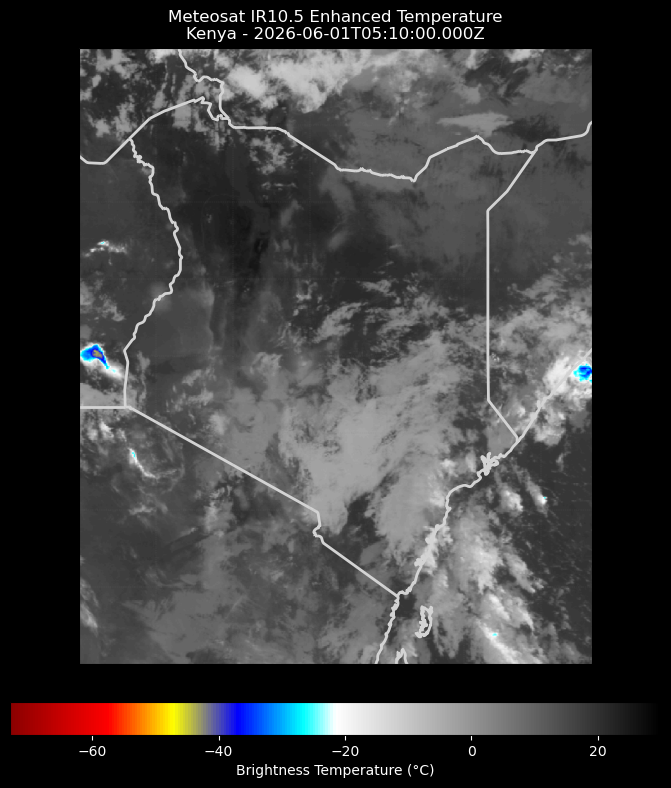

In [6]:
image = MTG_IR105_KENYA()
# 1. Convert image to single-channel array and scale to actual temperatures
img_array = np.array(image.convert('L')).astype(float)
temp_min = -73
temp_max = 30
img_temp = temp_max - (img_array / 255.0) * (temp_max - temp_min)

# 2. Build the EUMETView Segments 
# We define color nodes at exact temperature boundaries to replicate the website's look.
# Range: -73 C (Index 0.0) to 30 C (Index 1.0)
colors = [
    (0.0,  "darkred"),    # Ultra-cold convective cores (~ -73 C)
    (0.15, "red"),        # Intense storm tops
    (0.25, "yellow"),     # High-level convective transition
    (0.35, "blue"),       # Moderate-deep convection (~ -50 C)
    (0.45, "cyan"),       # Initial cold cloud enhancement threshold (~ -40 C)
    (0.50, "white"),      # Transition to standard cloud tops
    (0.75, "gray"),       # Mid-level/low clouds
    (1.0,  "black")       # Warm land/ocean surface (~ 30 C)
]

# Create the custom colormap linear segment object
eumet_cmap = mcolors.LinearSegmentedColormap.from_list("eumet_ir_enhanced", colors)

# 3. Plotting
fig = plt.figure(figsize=(12, 10), facecolor='black') # Match the dark environment view
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([33, 43, -6, 6], crs=ccrs.PlateCarree())

# Plot using our customized segmented colormap
im = ax.imshow(img_temp, origin='upper', extent=[33, 43, -6, 6], 
               transform=ccrs.PlateCarree(), cmap=eumet_cmap, vmin=-73, vmax=30)

# High contrast fine borders matching Eumetsat View 
ax.add_feature(cfeature.COASTLINE, color="lightgray", linewidth=2)
ax.add_feature(cfeature.BORDERS, color="lightgray", linewidth=2)

# Style gridlines minimally
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Add colorbar matching the palette tracking scheme
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('Brightness Temperature (°C)', color='white')
cbar.ax.xaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'xticklabels'), color='white')

plt.title(
    f"Meteosat IR10.5 Enhanced Temperature\nKenya - {latest_time}", 
    color='white', fontsize=12)
plt.show()